In [ ]:
# Title: 02_Ripa_BayesAge_calibration.ipynb
# Author: Lajoyce Mboning
# Date:2025
# Related publication: Emma K. Costa, and Jingxun Chen, in prep


# Description - Run the BayesAge clock on Ripa et al

# Set Up

In [1]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LassoCV
from numpy import arange
from numpy import absolute
from numpy import mean
from numpy import std
import numpy as np
from scipy import stats
from sklearn.metrics import mean_absolute_error as mae
import statsmodels.api as sm
from scipy.stats import spearmanr
lowess = sm.nonparametric.lowess
from scipy.stats import poisson
from scipy.stats import pearsonr
from datetime import datetime
import time
import random
import itertools
import os
import random
import pandas as pd
import numpy as np
from scipy.stats import poisson

In [2]:
#allow Google CoLab to have access to your drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# set working dir
# Get current notebook's directory
notebook_dir = '/content/drive/My Drive/african_killifish_atlas/revisions/CodeCheck_revisions/Ripa_model_outputs/BayesAge/'

# Set working directory (here it's just confirming it's already set)
os.chdir(notebook_dir)

In [4]:
# List of directories you want to create
dirs_to_create = [
    "./reference/",
    "./predictions/",
    "./gene_sets/",
    "./plots/",
    "./predictions_exhaustive/",
    "./reference_exhaustive/"
]


for d in dirs_to_create:
    os.makedirs(d, exist_ok=True)  # exist_ok=True won't raise an error if it already exists

In [5]:
def transcriptome_reference(training_matrix,
                        reference_name,
                        output_path="./predictions/",
                        age_prediction="list",
                        age_list=[],
                        min_age=-20,
                        max_age=100,
                        age_step=1,
                        tau=0.7,
                        ):

    start_time = time.time()

    training_cv_df = training_matrix

    training_df_frequency = training_cv_df.iloc[:,:-1]

    #print(training_df_frequency)

    training_df_frequency = training_df_frequency.div(training_df_frequency.sum(axis=1), axis=0)

    genes = training_cv_df.iloc[:,:-1].columns.tolist()

    age_steps = np.arange(min_age, max_age + age_step, age_step)

    # Age values from the reference data
    age_training = training_cv_df["age"].values.flatten()

    final_training_matrix = []

    if age_prediction == "list":

        for gene in genes:
            # Frequency level of current gene
            gene_frequency = training_df_frequency[gene].values.flatten()

            # Perform lowess smoothing
            predicted_frequency_levels = lowess(gene_frequency, age_training, xvals=age_list, frac=tau)

            # Calculate Spearman rank correlation
            rho, p = spearmanr(age_training, gene_frequency)

            spearman_rank = rho

            p_value = p

            final_gene_frequency_tuple = (gene, ) + tuple(predicted_frequency_levels) + (spearman_rank, p_value)

            final_training_matrix.append(final_gene_frequency_tuple)

        df_columns = ["Gene"] + [str(num) for num in age_list] + ["spearman_rank", "p_value"]

    elif age_prediction == "steps":

        for gene in genes:
            # Frequency level of current gene
            gene_frequency = training_df_frequency[gene].values.flatten()

            # Perform lowess smoothing
            predicted_frequency_levels = lowess(gene_frequency, age_training, xvals=age_steps, frac=tau)

            # Calculate Spearman rank correlation
            rho, p = spearmanr(age_training, gene_frequency)

            spearman_rank = rho

            p_value = p

            final_gene_frequency_tuple = (gene, ) + tuple(predicted_frequency_levels) + (spearman_rank, p_value)

            final_training_matrix.append(final_gene_frequency_tuple)

        df_columns = ["Gene"] + [str(num) for num in age_steps] + ["spearman_rank", "p_value"]


    df = pd.DataFrame(final_training_matrix, columns=df_columns)
    df.set_index("Gene", inplace=True)

    # Create output directory if it doesn't exist
    os.makedirs(output_path, exist_ok=True)

    # Save the DataFrame to a TSV file
    df.to_csv(os.path.join(output_path, reference_name), sep="\t")
    print(f"\nReference model dataset written to '{os.path.join(output_path, reference_name)}'")

    number_of_samples = training_cv_df.shape[0]

    # Write report file detailing input matrix
    report_file_path = os.path.join(output_path, f'{reference_name}.report.txt')
    with open(report_file_path, 'w') as writer:
        writer.write("BayesAge reference report for %s\n" % reference_name)
        now = datetime.now()
        write_datetime = now.strftime("%m/%d/%Y %H:%M:%S")
        writer.write("Reference file created: %s\n\n" % write_datetime)
        writer.write("Number of input samples = %s\n" % number_of_samples)
        writer.write("Number of input Genes = %s\n" % len(genes))
        if age_prediction == "list":
            writer.write("Predictions made for ages: %s\n" % age_list)
        elif age_prediction == "steps":
            writer.write("Predictions made for age steps from %s to %s with step %s\n" % (min_age, max_age, age_step))

    print(f"Report file generated at '{report_file_path}'")
    print("-----------------------------------------------------\n\n")

    end_time = time.time()
    elapsed_time = end_time - start_time
    print("\nTime to run construct reference: %0.3f seconds" % elapsed_time)
    print("\nThe reference is constructed and saved!")

    return df  # Optionally return the DataFrame

# Load & format atlas data

In [ ]:
# load raw counts
df_unnorm = pd.read_csv("../../AtlasFiles_forLajoyce_240507/Counts_Atlas_allbatches_merged_v3.csv")
df_unnorm.head(3)

,Unnamed: 0,A1_1,A1_2,A10_1,A10_2,A11_1,A11_2,A12_1,A12_2,A13_1,...,P4_2,P5_1,P5_2,P6_1,P6_2,P7_1,P7_2,P8_2,P9_1,P9_2
0,a1cf,21686,52,5891,6,7544,18,10043,9,0,...,12,45920,3113,9682,4020,37522,1383,36,7855,14
1,aaas,623,585,1108,720,824,1072,1004,611,192,...,484,310,143,336,487,178,148,735,1383,717
2,aacs,1980,502,266,1913,238,2252,308,1614,56,...,1061,6587,291,3347,552,329,178,1124,382,1232


In [ ]:
df_unnorm.rename(columns={"Unnamed: 0": "sample"}, inplace=True)
df_unnorm.set_index("sample", inplace=True)
df_unnorm.head(3)

,A1_1,A1_2,A10_1,A10_2,A11_1,A11_2,A12_1,A12_2,A13_1,A13_2,...,P4_2,P5_1,P5_2,P6_1,P6_2,P7_1,P7_2,P8_2,P9_1,P9_2
sample,,,,,,,,,,,,,,,,,,,,,
a1cf,21686,52,5891,6,7544,18,10043,9,0,30,...,12,45920,3113,9682,4020,37522,1383,36,7855,14
aaas,623,585,1108,720,824,1072,1004,611,192,591,...,484,310,143,336,487,178,148,735,1383,717
aacs,1980,502,266,1913,238,2252,308,1614,56,227,...,1061,6587,291,3347,552,329,178,1124,382,1232


In [ ]:
df_unnorm = df_unnorm.T
df_unnorm.head(3)

sample,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim6,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3
A1_1,21686,623,1980,523,200,802,1242,1224,562,577,...,829,161,1014,220,1560,42,515,3018,1422,325
A1_2,52,585,502,537,709,674,1385,2329,652,646,...,1113,92,963,153,1118,27,966,3871,275,364
A10_1,5891,1108,266,676,233,835,1374,809,716,778,...,635,156,1650,137,1370,380,662,3191,498,477


In [ ]:
# load metadata
df_metadata = pd.read_csv("../../AtlasFiles_forLajoyce_240507/ExperimentDesign_allbatches_combined_v7.csv")

df_metadata.head(3)

/usr/local/lib/python3.11/dist-packages/google/colab/_dataframe_summarizer.py:88: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  cast_date_col = pd.to_datetime(column, errors="coerce")


,Unnamed: 0,animalID,sex,cohort,age_days,harvest_date,hatch_date,tissue,tissue_grind_date,RNA_extract_date,RNA_batch,RNA_extractor,RNAID,cDNA_batch,plate_well,sampleNames,lib,censored,censor_code,notes
0,A1_1,J9,F,2,155,8/16/22,3/14/22,Gut,NaN,3/8/23,Gut_1,EC,RNA352,1,A1,A1,A1_1,NaN,NaN,NaN
1,A1_2,A01,M,2,78,5/31/22,3/14/22,Bone,4/19/23,4/22/23,Bone_1,EC,RNA572,2,A1,A1,A1_2,NaN,NaN,NaN
2,A10_1,P_1B_10,M,1B,133,1/31/22,9/20/21,Kidney,NaN,3/4/23,Kidney_1,JC,R258,1,A10,A10,A10_1,NaN,NaN,NaN


In [ ]:
df_metadata.reset_index()

,index,Unnamed: 0,animalID,sex,cohort,age_days,harvest_date,hatch_date,tissue,tissue_grind_date,...,RNA_batch,RNA_extractor,RNAID,cDNA_batch,plate_well,sampleNames,lib,censored,censor_code,notes
0,0,A1_1,J9,F,2,155,8/16/22,3/14/22,Gut,NaN,...,Gut_1,EC,RNA352,1,A1,A1,A1_1,NaN,NaN,NaN
1,1,A1_2,A01,M,2,78,5/31/22,3/14/22,Bone,4/19/23,...,Bone_1,EC,RNA572,2,A1,A1,A1_2,NaN,NaN,NaN
2,2,A10_1,P_1B_10,M,1B,133,1/31/22,9/20/21,Kidney,NaN,...,Kidney_1,JC,R258,1,A10,A10,A10_1,NaN,NaN,NaN
3,3,A10_2,J_1A_14,M,1A,75,11/22/21,9/8/21,SpinalCord,NaN,...,SpinalCord_1,EC,RNA423,2,A10,A10,A10_2,NaN,NaN,NaN
4,4,A11_1,J_1A_22,M,1A,47,10/25/21,9/8/21,Kidney,NaN,...,Kidney_2,JC,R274,1,A11,A11,A11_1,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
672,672,P7_1,J_1A_25,M,1A,103,12/20/21,9/8/21,Liver,NaN,...,Liver_1,IG,RNA689,1,P7,P7,P7_1,NaN,NaN,NaN
673,673,P7_2,P_1B_1,F,1B,77,12/6/21,9/20/21,Fat,4/13/23,...,Fat_3,EC,RNA566,2,P7,P7,P7_2,NaN,NaN,NaN
674,674,P8_2,J_1A_25,M,1A,103,12/20/21,9/8/21,Eye,NaN,...,Eye_1,MRW,642,2,P8,P8,P8_2,NaN,NaN,NaN
675,675,P9_1,J_1B_2,M,1B,49,11/8/21,9/20/21,Kidney,NaN,...,Kidney_1,JC,R257,1,P9,P9,P9_1,NaN,NaN,NaN


In [ ]:
df_metadata.rename(columns={"Unnamed: 0": "sample"}, inplace=True)

df_metadata.head(3)

/usr/local/lib/python3.11/dist-packages/google/colab/_dataframe_summarizer.py:88: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  cast_date_col = pd.to_datetime(column, errors="coerce")


,sample,animalID,sex,cohort,age_days,harvest_date,hatch_date,tissue,tissue_grind_date,RNA_extract_date,RNA_batch,RNA_extractor,RNAID,cDNA_batch,plate_well,sampleNames,lib,censored,censor_code,notes
0,A1_1,J9,F,2,155,8/16/22,3/14/22,Gut,NaN,3/8/23,Gut_1,EC,RNA352,1,A1,A1,A1_1,NaN,NaN,NaN
1,A1_2,A01,M,2,78,5/31/22,3/14/22,Bone,4/19/23,4/22/23,Bone_1,EC,RNA572,2,A1,A1,A1_2,NaN,NaN,NaN
2,A10_1,P_1B_10,M,1B,133,1/31/22,9/20/21,Kidney,NaN,3/4/23,Kidney_1,JC,R258,1,A10,A10,A10_1,NaN,NaN,NaN


In [ ]:
df_metadata.set_index("sample", inplace=True)
df_metadata.head(2)

/usr/local/lib/python3.11/dist-packages/google/colab/_dataframe_summarizer.py:88: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  cast_date_col = pd.to_datetime(column, errors="coerce")


,animalID,sex,cohort,age_days,harvest_date,hatch_date,tissue,tissue_grind_date,RNA_extract_date,RNA_batch,RNA_extractor,RNAID,cDNA_batch,plate_well,sampleNames,lib,censored,censor_code,notes
sample,,,,,,,,,,,,,,,,,,,
A1_1,J9,F,2,155,8/16/22,3/14/22,Gut,NaN,3/8/23,Gut_1,EC,RNA352,1,A1,A1,A1_1,NaN,NaN,NaN
A1_2,A01,M,2,78,5/31/22,3/14/22,Bone,4/19/23,4/22/23,Bone_1,EC,RNA572,2,A1,A1,A1_2,NaN,NaN,NaN


In [ ]:
# Merge based on index
combined_df = pd.concat([df_unnorm, df_metadata[['sex', 'tissue', 'age_days']]], axis=1)
combined_df.rename(columns={"age_days": "age"}, inplace=True)
combined_df.head(3)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age
A1_1,21686,623,1980,523,200,802,1242,1224,562,577,...,220,1560,42,515,3018,1422,325,F,Gut,155
A1_2,52,585,502,537,709,674,1385,2329,652,646,...,153,1118,27,966,3871,275,364,M,Bone,78
A10_1,5891,1108,266,676,233,835,1374,809,716,778,...,137,1370,380,662,3191,498,477,M,Kidney,133


# Load & format intervention data

In [ ]:
#raw counts from intervention dataset
df_intervention = pd.read_csv("../../Data_from_Others/Antebi_Fat_Ripa_etal_2023/Counts_AntebiFat_250412.csv")
df_intervention.head(3)

,young_fed_wt_fat_rep_4,young_fasted_wt_fat_rep_1,young_fasted_wt_fat_rep_2,young_fasted_wt_fat_rep_3,young_fasted_wt_fat_rep_4,young_fed_mut_fat_rep_1,young_fed_mut_fat_rep_2,old_fed_wt_fat_rep_4,young_fed_mut_fat_rep_3,young_fed_mut_fat_rep_4,...,old_fasted_mut_fat_rep_3,old_fasted_mut_fat_rep_2,old_fasted_mut_fat_rep_1,old_fed_mut_fat_rep_5,old_fed_mut_fat_rep_4,old_fed_mut_fat_rep_3,old_fed_mut_fat_rep_2,old_fed_mut_fat_rep_1,old_fed_wt_fat_rep_2,old_fed_wt_fat_rep_1
LOC107389033,16,92,29,56,48,76,90,353,84,47,...,405,374,143,142,190,104,67,268,287,319
LOC107383083,0,12,0,2,6,8,0,0,2,0,...,10,28,24,0,8,15,10,6,4,4
LOC107396907,8,77,39,55,53,130,179,172,111,92,...,323,190,103,88,202,65,92,220,223,126


In [ ]:
df_intervention = df_intervention.T
df_intervention.head(2)

,LOC107389033,LOC107383083,LOC107396907,LOC107392678,LOC107395313,LOC107380939,LOC107383105,cdkn2aipnl,LOC107396968,acss3,...,LOC107397194,LOC107383692,LOC107375174,c2cd4c,ccdc115,LOC107385112,ddx42,LOC107381819,srek1ip1,LOC107388320
young_fed_wt_fat_rep_4,16,0,8,4,15,0,82,87,33,261,...,127,320,0,0,58,16,392,246,129,7
young_fasted_wt_fat_rep_1,92,12,77,24,40,10,226,114,97,402,...,456,906,15,50,247,176,1001,439,283,65


In [ ]:
df_intervention_metadata = pd.read_csv("../../Data_from_Others/Antebi_Fat_Ripa_etal_2023/ExperimentDesign_AntebiFat_update_20250629.csv")
df_intervention_metadata.set_index("Sample.Name", inplace=True)
df_intervention_metadata.head(2)

,Run,AGE,Assay.Type,AvgSpotLen,Bases,BioProject,BioSample,BioSampleModel,Bytes,Center.Name,...,ReleaseDate,create_date,version,sex,SRA.Study,strain,tissue,file,lib,UsedForTraining
Sample.Name,,,,,,,,,,,,,,,,,,,,,
young_fed_wt_fat_rep_4,SRR18362991,Young (7 weeks),RNA-Seq,202,6623920370,PRJNA817434,SAMN26788046,Model organism or animal,1964305779,MAX PLANCK INSTITUTE FOR BIOLOGY OF AGEING,...,2022-03-20T00:00:00Z,2022-03-20T03:18:00Z,1,male,SRP364776,GRZ_AD wild_type,Visceral adipose tissue,SRR18362991.featureCounts,SRR18362991,Yes
young_fasted_wt_fat_rep_1,SRR18362992,Young (7 weeks),RNA-Seq,202,7410627954,PRJNA817434,SAMN26788047,Model organism or animal,2234922451,MAX PLANCK INSTITUTE FOR BIOLOGY OF AGEING,...,2022-03-20T00:00:00Z,2022-03-20T03:46:00Z,1,male,SRP364776,GRZ_AD wild_type,Visceral adipose tissue,SRR18362992.featureCounts,SRR18362992,No


In [ ]:
# Parse the index and extract components
df_intervention[['age_group', 'treatment', 'genotype', 'tissue']] = df_intervention.index.to_series().str.extract(
    r'^(.*?)_(.*?)_(.*?)_(.*?)_rep_\d+$'
)
df_intervention.head(2)

,LOC107389033,LOC107383083,LOC107396907,LOC107392678,LOC107395313,LOC107380939,LOC107383105,cdkn2aipnl,LOC107396968,acss3,...,ccdc115,LOC107385112,ddx42,LOC107381819,srek1ip1,LOC107388320,age_group,treatment,genotype,tissue
young_fed_wt_fat_rep_4,16,0,8,4,15,0,82,87,33,261,...,58,16,392,246,129,7,young,fed,wt,fat
young_fasted_wt_fat_rep_1,92,12,77,24,40,10,226,114,97,402,...,247,176,1001,439,283,65,young,fasted,wt,fat


In [ ]:
age_mapping = {
    "young": 49,
    "old": 126
}

df_intervention["age"] = df_intervention["age_group"].map(age_mapping)
df_intervention.head(2)

,LOC107389033,LOC107383083,LOC107396907,LOC107392678,LOC107395313,LOC107380939,LOC107383105,cdkn2aipnl,LOC107396968,acss3,...,LOC107385112,ddx42,LOC107381819,srek1ip1,LOC107388320,age_group,treatment,genotype,tissue,age
young_fed_wt_fat_rep_4,16,0,8,4,15,0,82,87,33,261,...,16,392,246,129,7,young,fed,wt,fat,49
young_fasted_wt_fat_rep_1,92,12,77,24,40,10,226,114,97,402,...,176,1001,439,283,65,young,fasted,wt,fat,49


In [ ]:
df_intervention['tissue'] = df_intervention['tissue'].replace('fat', 'Fat')
df_intervention['sex'] = 'M'

select_tissue = 'Fat'

# Male - fat

In [ ]:
df_intervention_male = df_intervention.copy()

In [ ]:
random.seed(123)

all_samples = df_intervention_male.index

#select two AL-WT samples for calibration
WT_samples = df_intervention_male[df_intervention_male['genotype'] == 'wt'].index

#get rid of fed samples, remove the test samples that have "fasted" in the name
WT_samples = [s for s in WT_samples if 'fasted' not in s.lower()]
WT_samples = sorted(WT_samples)
WT_samples


# Separate the samples
young_samples = [s for s in WT_samples if s.startswith("young")]
old_samples = [s for s in WT_samples if s.startswith("old")]

# Randomly sample 2 from each
random_young = random.sample(young_samples, 2)
random_old = random.sample(old_samples, 2)

# Combine the result
random_subset = random_young + random_old

#select your training samples
select_train_samples = random_subset

df_intervention_train = df_intervention_male.loc[
    df_intervention_male.index.isin(select_train_samples)
]

df_intervention_train.head()

,LOC107389033,LOC107383083,LOC107396907,LOC107392678,LOC107395313,LOC107380939,LOC107383105,cdkn2aipnl,LOC107396968,acss3,...,ddx42,LOC107381819,srek1ip1,LOC107388320,age_group,treatment,genotype,tissue,age,sex
old_fed_wt_fat_rep_4,353,0,172,18,42,6,187,150,115,321,...,931,486,182,96,old,fed,wt,Fat,126,M
young_fed_wt_fat_rep_1,44,2,63,4,13,4,110,115,66,365,...,556,261,141,21,young,fed,wt,Fat,49,M
young_fed_wt_fat_rep_2,30,2,54,0,11,2,66,74,45,314,...,374,163,42,21,young,fed,wt,Fat,49,M
old_fed_wt_fat_rep_1,319,4,126,18,43,4,284,159,124,330,...,985,595,207,36,old,fed,wt,Fat,126,M


In [ ]:
# get your testing samples
#all not in select_train_samples
test_samples = [s for s in all_samples if s not in select_train_samples]
test_samples

['young_fed_wt_fat_rep_4',
 'young_fasted_wt_fat_rep_1',
 'young_fasted_wt_fat_rep_2',
 'young_fasted_wt_fat_rep_3',
 'young_fasted_wt_fat_rep_4',
 'young_fed_mut_fat_rep_1',
 'young_fed_mut_fat_rep_2',
 'young_fed_mut_fat_rep_3',
 'young_fed_mut_fat_rep_4',
 'young_fasted_mut_fat_rep_1',
 'young_fasted_mut_fat_rep_2',
 'young_fasted_mut_fat_rep_3',
 'young_fasted_mut_fat_rep_4',
 'old_fed_wt_fat_rep_5',
 'old_fasted_wt_fat_rep_1',
 'old_fasted_wt_fat_rep_2',
 'old_fasted_wt_fat_rep_3',
 'old_fasted_wt_fat_rep_4',
 'old_fasted_wt_fat_rep_5',
 'old_fed_wt_fat_rep_3',
 'young_fed_wt_fat_rep_3',
 'old_fasted_mut_fat_rep_5',
 'old_fasted_mut_fat_rep_4',
 'old_fasted_mut_fat_rep_3',
 'old_fasted_mut_fat_rep_2',
 'old_fasted_mut_fat_rep_1',
 'old_fed_mut_fat_rep_5',
 'old_fed_mut_fat_rep_4',
 'old_fed_mut_fat_rep_3',
 'old_fed_mut_fat_rep_2',
 'old_fed_mut_fat_rep_1',
 'old_fed_wt_fat_rep_2']

In [ ]:
# Select rows in df_intervention_age_counts_female where index is in female_samples
df_intervention_test = df_intervention.loc[
    df_intervention.index.isin(test_samples)
]

df_intervention_test.head(3)

,LOC107389033,LOC107383083,LOC107396907,LOC107392678,LOC107395313,LOC107380939,LOC107383105,cdkn2aipnl,LOC107396968,acss3,...,ddx42,LOC107381819,srek1ip1,LOC107388320,age_group,treatment,genotype,tissue,age,sex
young_fed_wt_fat_rep_4,16,0,8,4,15,0,82,87,33,261,...,392,246,129,7,young,fed,wt,Fat,49,M
young_fasted_wt_fat_rep_1,92,12,77,24,40,10,226,114,97,402,...,1001,439,283,65,young,fasted,wt,Fat,49,M
young_fasted_wt_fat_rep_2,29,0,39,10,22,6,128,69,73,268,...,535,361,73,6,young,fasted,wt,Fat,49,M


### Male - transcriptome reference

In [ ]:
# Specify the path for the new directory for the tissue
directory_path = "./fat/"

# Create the directory
os.mkdir(directory_path)

In [ ]:
#select raw counts
tissue_df_counts = combined_df.loc[
    (combined_df.iloc[:, -2] == select_tissue) &
    (combined_df.iloc[:, -3] == 'M')
]
tissue_df_counts['treatment'] = 'AL'
tissue_df_counts.head(5)

/tmp/ipython-input-3975167852.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tissue_df_counts['treatment'] = 'AL'


,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age,treatment
A5_2,4017,132,317,205,106,293,711,322,297,198,...,597,26,183,780,128,186,M,Fat,52,AL
A6_2,3879,677,129,461,267,628,974,363,668,484,...,682,192,406,3948,245,272,M,Fat,77,AL
A8_2,2692,257,197,297,83,218,627,223,165,148,...,462,56,314,884,138,211,M,Fat,103,AL
B7_2,2362,708,185,463,377,580,833,679,488,622,...,819,155,426,4170,253,329,M,Fat,102,AL
B8_2,1579,227,127,178,160,356,497,451,375,183,...,520,98,243,1060,111,152,M,Fat,152,AL


In [ ]:
df_intervention_train = df_intervention_train[tissue_df_counts.columns]
df_intervention_train.head(2)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age,treatment
old_fed_wt_fat_rep_4,4874,216,527,222,184,290,843,534,228,182,...,448,59,847,1872,1743,802,M,Fat,126,fed
young_fed_wt_fat_rep_1,2858,211,349,219,106,255,656,350,275,138,...,580,42,569,1213,1599,544,M,Fat,49,fed


In [ ]:
atlas_plus_intervention = pd.concat([tissue_df_counts, df_intervention_train], axis=0)
atlas_plus_intervention.head(3)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age,treatment
A5_2,4017,132,317,205,106,293,711,322,297,198,...,597,26,183,780,128,186,M,Fat,52,AL
A6_2,3879,677,129,461,267,628,974,363,668,484,...,682,192,406,3948,245,272,M,Fat,77,AL
A8_2,2692,257,197,297,83,218,627,223,165,148,...,462,56,314,884,138,211,M,Fat,103,AL


In [ ]:
# #check cols ordered the same
# df_intervention_test = df_intervention_test[tissue_df_counts.columns]
# df_intervention_test.head(2)

In [ ]:
tissue_age_days_value_counts = atlas_plus_intervention["age"].value_counts().index.tolist()

In [ ]:
age_steps = sorted(tissue_age_days_value_counts)

print(age_steps)

[47, 49, 52, 75, 77, 78, 102, 103, 126, 133, 134, 147, 152, 161, 162]


In [ ]:
atlas_plus_intervention_age = atlas_plus_intervention.drop(atlas_plus_intervention.columns[[-1,-3, -4]], axis=1)
atlas_plus_intervention_age.head(2)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,age
A5_2,4017,132,317,205,106,293,711,322,297,198,...,27,468,43,597,26,183,780,128,186,52
A6_2,3879,677,129,461,267,628,974,363,668,484,...,82,1128,187,682,192,406,3948,245,272,77


In [ ]:
#sample generation
for sample in atlas_plus_intervention_age.index.tolist():

    new_df = atlas_plus_intervention_age.drop(sample)

    new_df.to_csv(f"./fat/fat_sample_{sample}.csv", sep="\t")

In [ ]:
new_age_steps = np.arange(min(age_steps), max(age_steps)+1, 1)

In [ ]:
# Specify the path for the new directory for the tissue
directory_path = "./fat/reference"

# Create the directory
os.mkdir(directory_path)

In [ ]:
transcriptome_reference(training_matrix= atlas_plus_intervention_age,
                            reference_name="killifish_fat_reference_male",
                            output_path="./fat/reference/",
                            age_prediction="list",
                            age_list=new_age_steps,
                            min_age=1,
                            max_age=24,
                            age_step=1,
                            tau=0.7)

/tmp/ipython-input-2002720175.py:41: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p = spearmanr(age_training, gene_frequency)



Reference model dataset written to './fat/reference/killifish_fat_reference_male'
Report file generated at './fat/reference/killifish_fat_reference_male.report.txt'
-----------------------------------------------------



Time to run construct reference: 67.900 seconds

The reference is constructed and saved!


,47,48,49,50,51,52,53,54,55,56,...,155,156,157,158,159,160,161,162,spearman_rank,p_value
Gene,,,,,,,,,,,,,,,,,,,,,
a1cf,0.000128,0.000128,0.000128,0.000127,0.000127,0.000127,0.000127,0.000127,0.000127,0.000127,...,0.000146,0.000146,0.000147,0.000147,0.000148,0.000149,0.000149,0.000150,0.130985,0.460279
aaas,0.000008,0.000008,0.000008,0.000008,0.000008,0.000008,0.000008,0.000008,0.000008,0.000008,...,0.000011,0.000011,0.000011,0.000011,0.000011,0.000011,0.000012,0.000012,0.235926,0.179185
aacs,0.000010,0.000010,0.000010,0.000010,0.000010,0.000010,0.000010,0.000010,0.000009,0.000009,...,0.000015,0.000015,0.000016,0.000016,0.000016,0.000016,0.000016,0.000016,0.259978,0.137574
aadat,0.000008,0.000008,0.000008,0.000008,0.000008,0.000008,0.000008,0.000008,0.000008,0.000008,...,0.000009,0.000009,0.000009,0.000009,0.000009,0.000009,0.000009,0.000009,0.165454,0.349717
aaed1,0.000005,0.000005,0.000005,0.000005,0.000005,0.000005,0.000005,0.000005,0.000005,0.000005,...,0.000008,0.000008,0.000008,0.000008,0.000008,0.000008,0.000008,0.000008,0.428496,0.011459
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
zwilch,0.000002,0.000002,0.000002,0.000002,0.000002,0.000002,0.000002,0.000002,0.000002,0.000002,...,0.000003,0.000003,0.000003,0.000003,0.000003,0.000003,0.000003,0.000003,0.255535,0.144669
zyg11b,0.000006,0.000006,0.000007,0.000007,0.000007,0.000007,0.000007,0.000007,0.000007,0.000008,...,0.000014,0.000014,0.000014,0.000014,0.000014,0.000014,0.000014,0.000014,0.255842,0.144171
zyx,0.000035,0.000035,0.000035,0.000035,0.000036,0.000036,0.000036,0.000036,0.000036,0.000036,...,0.000052,0.000052,0.000052,0.000052,0.000052,0.000052,0.000052,0.000052,0.278821,0.110303


In [ ]:
df_intervention_test_counts = df_intervention_test.drop(df_intervention_test.columns[[-1,-2,-3, -4, -5,-6]], axis=1)
df_intervention_test_counts.head(3)

,LOC107389033,LOC107383083,LOC107396907,LOC107392678,LOC107395313,LOC107380939,LOC107383105,cdkn2aipnl,LOC107396968,acss3,...,LOC107397194,LOC107383692,LOC107375174,c2cd4c,ccdc115,LOC107385112,ddx42,LOC107381819,srek1ip1,LOC107388320
young_fed_wt_fat_rep_4,16,0,8,4,15,0,82,87,33,261,...,127,320,0,0,58,16,392,246,129,7
young_fasted_wt_fat_rep_1,92,12,77,24,40,10,226,114,97,402,...,456,906,15,50,247,176,1001,439,283,65
young_fasted_wt_fat_rep_2,29,0,39,10,22,6,128,69,73,268,...,287,682,0,0,40,82,535,361,73,6


In [ ]:
gene_number = 15
df_intervention_test_pred = pd.DataFrame(index=df_intervention_test.index, columns=["prediction"])

for sample in df_intervention_test.index.tolist():

    reference_df = pd.read_csv(f"./fat/reference/killifish_fat_reference_male", sep="\t", index_col=0)

    # Get top genes based on spearman correlation
    top_abs_spearman_corr = reference_df["spearman_rank"].abs().nlargest(gene_number)

    #print(top_abs_spearman_corr)

    top_genes = top_abs_spearman_corr.index.tolist()

    # Save the DataFrame to a CSV file
    # df_top_genes = pd.DataFrame(top_genes, columns=["genes"])
    # gene_num = "".join([str(gene_number), "genes"])
    # out_file_prefix = 'Antebi_male_pred'
    # out_file_name = "_".join([out_file_prefix, gene_num])
    # output_path = './fat/gene_sets'
    # df_top_genes.to_csv(os.path.join(output_path, out_file_name), sep="\t")
    # print(f"List has been written to {out_file_name}")

    total_reads_sample = df_intervention_test_counts.loc[sample].sum()

    list_of_profile_probabilities_per_age = []

    for age in new_age_steps:

        probability_list_one_age = []

        genes_not_defined = []

        for gene in top_genes:

            gene_frequency = reference_df.loc[gene, f"{age}"]

            if gene_frequency < 0:
                gene_frequency = 10**-10

            sample_expected_counts = gene_frequency * total_reads_sample
            sample_observed_counts = df_intervention_test_counts.loc[sample, gene]

            poisson_probability = poisson.pmf(k=sample_observed_counts, mu=sample_expected_counts)

            # Replace NaN poisson probability with a small positive value and log it
            if np.isnan(poisson_probability):
                poisson_probability = 0.001
                genes_not_defined.append(gene)

            # Replace zero poisson probability with 0.001
            if poisson_probability == 0:
                poisson_probability = 0.001

            logP = np.log(poisson_probability)

            probability_list_one_age.append(logP)

        list_of_profile_probabilities_per_age.append(np.sum(probability_list_one_age))

    # Transform into dataframe with age steps
    age_probability_df = pd.DataFrame({"Pr": list_of_profile_probabilities_per_age}, index=new_age_steps)

    # Compute highest likelihood age among age steps
    max_probability_age = round(float(age_probability_df.idxmax().iloc[0]), 2)

    # Compute highest maximum probability
    max_probability = float(age_probability_df["Pr"].max())

    df_intervention_test_pred.loc[sample, "prediction"] = max_probability_age



print(df_intervention_test_pred)

                           prediction
young_fed_wt_fat_rep_4           47.0
young_fasted_wt_fat_rep_1        47.0
young_fasted_wt_fat_rep_2        47.0
young_fasted_wt_fat_rep_3        47.0
young_fasted_wt_fat_rep_4        47.0
young_fed_mut_fat_rep_1          47.0
young_fed_mut_fat_rep_2          81.0
young_fed_mut_fat_rep_3          52.0
young_fed_mut_fat_rep_4          47.0
young_fasted_mut_fat_rep_1       71.0
young_fasted_mut_fat_rep_2       47.0
young_fasted_mut_fat_rep_3       95.0
young_fasted_mut_fat_rep_4       54.0
old_fed_wt_fat_rep_5             52.0
old_fasted_wt_fat_rep_1          48.0
old_fasted_wt_fat_rep_2         120.0
old_fasted_wt_fat_rep_3          67.0
old_fasted_wt_fat_rep_4          70.0
old_fasted_wt_fat_rep_5          79.0
old_fed_wt_fat_rep_3             67.0
young_fed_wt_fat_rep_3           47.0
old_fasted_mut_fat_rep_5         90.0
old_fasted_mut_fat_rep_4        145.0
old_fasted_mut_fat_rep_3         80.0
old_fasted_mut_fat_rep_2         92.0
old_fasted_m

In [ ]:
df_intervention_test_pred["treatment"] = df_intervention_test["treatment"].tolist()
df_intervention_test_pred["genotype"] = df_intervention_test["genotype"].tolist()
df_intervention_test_pred["age"] = df_intervention_test["age"].tolist()

df_intervention_test_pred["age_genotype_treatment"] = (
    df_intervention_test_pred["age"].astype(str) + "_" +
    df_intervention_test_pred["genotype"].astype(str) + "_" +
    df_intervention_test_pred["treatment"].astype(str)
)

df_intervention_test_pred

,prediction,treatment,genotype,age,age_genotype_treatment
young_fed_wt_fat_rep_4,47.0,fed,wt,49,49_wt_fed
young_fasted_wt_fat_rep_1,47.0,fasted,wt,49,49_wt_fasted
young_fasted_wt_fat_rep_2,47.0,fasted,wt,49,49_wt_fasted
young_fasted_wt_fat_rep_3,47.0,fasted,wt,49,49_wt_fasted
young_fasted_wt_fat_rep_4,47.0,fasted,wt,49,49_wt_fasted
young_fed_mut_fat_rep_1,47.0,fed,mut,49,49_mut_fed
young_fed_mut_fat_rep_2,81.0,fed,mut,49,49_mut_fed
young_fed_mut_fat_rep_3,52.0,fed,mut,49,49_mut_fed
young_fed_mut_fat_rep_4,47.0,fed,mut,49,49_mut_fed
young_fasted_mut_fat_rep_1,71.0,fasted,mut,49,49_mut_fasted


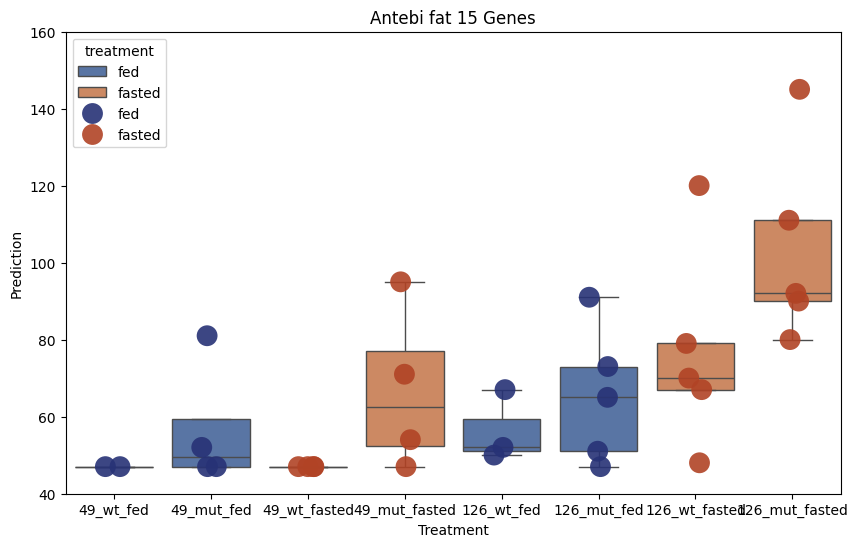

In [ ]:
ordered_x = [
    '49_wt_fed', '49_mut_fed',
    '49_wt_fasted', '49_mut_fasted',
    '126_wt_fed', '126_mut_fed',
    '126_wt_fasted', '126_mut_fasted'
]


# Create the box plot
plt.figure(figsize=(10, 6))
box = sns.boxplot(x='age_genotype_treatment', y='prediction', hue='treatment', data=df_intervention_test_pred, palette='deep', showfliers = False,
    order = ordered_x)

# Add data points

custom_palette = ['#273276', '#B14325']  # Use desired hex color codes

# Add data points with custom colors
strip = sns.stripplot(
    x='age_genotype_treatment',
    y='prediction',
    hue='treatment',
    data=df_intervention_test_pred,
    palette=custom_palette,  # Custom color palette
    dodge=False,
    alpha=0.9,
    jitter=True,
    size=15,
    order = ordered_x
)

# Remove the legend if not needed
#strip.legend_.remove()

# Customize the plot
plt.title("".join(['Antebi fat ', str(gene_number), ' Genes']))
plt.xlabel('Treatment')
plt.ylabel('Prediction')

# Set y-axis limits
plt.ylim(40, 160)

# Remove the grid
plt.grid(False)

#plt.savefig("".join(["./plots/liver_CR_top_",str(gene_number),"_genes.svg"]), dpi=300, bbox_inches="tight")

# Show the plot
plt.show()

In [ ]:
df_intervention_test_pred.to_csv("./df_prediction_BayesAge_sex_specific_ripa_male.csv", sep="\t")

### Try several gene set sizes

In [ ]:
# Set up ordered x-axis for plots
ordered_x = [
    '49_wt_fed', '49_mut_fed',
    '49_wt_fasted', '49_mut_fasted',
    '126_wt_fed', '126_mut_fed',
    '126_wt_fasted', '126_mut_fasted'
]

# Custom color palette
custom_palette = ['#273276', '#B14325']

# Directory setup
os.makedirs("./predictions", exist_ok=True)
os.makedirs("./plots", exist_ok=True)

# Dictionary to store prediction DataFrames if needed later
all_predictions = {}

# Loop through gene numbers
for gene_number in range(5, 51, 5):
    print(f"Running prediction for top {gene_number} genes...")

    df_intervention_test_pred = pd.DataFrame(index=df_intervention_test.index, columns=["prediction"])

    for sample in df_intervention_test.index.tolist():
        reference_df = pd.read_csv(f"./fat/reference/killifish_fat_reference_male", sep="\t", index_col=0)
        top_genes = reference_df["spearman_rank"].abs().nlargest(gene_number).index.tolist()

        total_reads_sample = df_intervention_test_counts.loc[sample].sum()
        list_of_profile_probabilities_per_age = []

        for age in new_age_steps:
            log_probs = []
            for gene in top_genes:
                gene_frequency = reference_df.loc[gene, str(age)]
                gene_frequency = max(gene_frequency, 1e-10)  # Ensure >0

                expected = gene_frequency * total_reads_sample
                observed = df_intervention_test_counts.loc[sample, gene]

                poisson_prob = poisson.pmf(k=observed, mu=expected)
                poisson_prob = max(poisson_prob, 0.001)

                log_probs.append(np.log(poisson_prob))

            list_of_profile_probabilities_per_age.append(np.sum(log_probs))

        age_probability_df = pd.DataFrame({"Pr": list_of_profile_probabilities_per_age}, index=new_age_steps)
        max_probability_age = round(float(age_probability_df.idxmax().iloc[0]), 2)
        df_intervention_test_pred.loc[sample, "prediction"] = max_probability_age

    # Add metadata
    df_intervention_test_pred["treatment"] = df_intervention_test["treatment"].tolist()
    df_intervention_test_pred["genotype"] = df_intervention_test["genotype"].tolist()
    df_intervention_test_pred["age"] = df_intervention_test["age"].tolist()
    df_intervention_test_pred["age_genotype_treatment"] = (
        df_intervention_test_pred["age"].astype(str) + "_" +
        df_intervention_test_pred["genotype"].astype(str) + "_" +
        df_intervention_test_pred["treatment"].astype(str)
    )

    # Save predictions
    all_predictions[gene_number] = df_intervention_test_pred.copy()
    df_intervention_test_pred.to_csv(f"./predictions/age_preds_top_{gene_number}_genes.tsv", sep="\t")

    # --- Plot ---
    plt.figure(figsize=(10, 6))

    box = sns.boxplot(
        x='age_genotype_treatment',
        y='prediction',
        hue='treatment',
        data=df_intervention_test_pred,
        palette='deep',
        showfliers=False,
        order=ordered_x
    )

    strip = sns.stripplot(
        x='age_genotype_treatment',
        y='prediction',
        hue='treatment',
        data=df_intervention_test_pred,
        palette=custom_palette,
        dodge=False,
        alpha=0.9,
        jitter=True,
        size=15,
        order=ordered_x
    )

    # Remove duplicate legend
    strip.legend_.remove()

    plt.title(f"Antebi fat {gene_number} Genes")
    plt.xlabel('Treatment')
    plt.ylabel('Prediction')
    plt.xticks(rotation=45, ha='right')
    plt.ylim(40, 160)
    plt.grid(False)

    # Save plot
    plt.savefig(f"./plots/antebi_fat_top_{gene_number}_genes.svg", dpi=300, bbox_inches="tight")
    plt.close()

    print(f"Saved plot and prediction for {gene_number} genes.\n")


Running prediction for top 5 genes...
Saved plot and prediction for 5 genes.

Running prediction for top 10 genes...
Saved plot and prediction for 10 genes.

Running prediction for top 15 genes...
Saved plot and prediction for 15 genes.

Running prediction for top 20 genes...
Saved plot and prediction for 20 genes.

Running prediction for top 25 genes...
Saved plot and prediction for 25 genes.

Running prediction for top 30 genes...
Saved plot and prediction for 30 genes.

Running prediction for top 35 genes...
Saved plot and prediction for 35 genes.

Running prediction for top 40 genes...
Saved plot and prediction for 40 genes.

Running prediction for top 45 genes...
Saved plot and prediction for 45 genes.

Running prediction for top 50 genes...
Saved plot and prediction for 50 genes.



### plot stability of preds

/tmp/ipython-input-3893830331.py:66: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
/tmp/ipython-input-3893830331.py:66: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
/tmp/ipython-input-3893830331.py:66: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
/tmp/ipython-input-3893830331.py:66: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


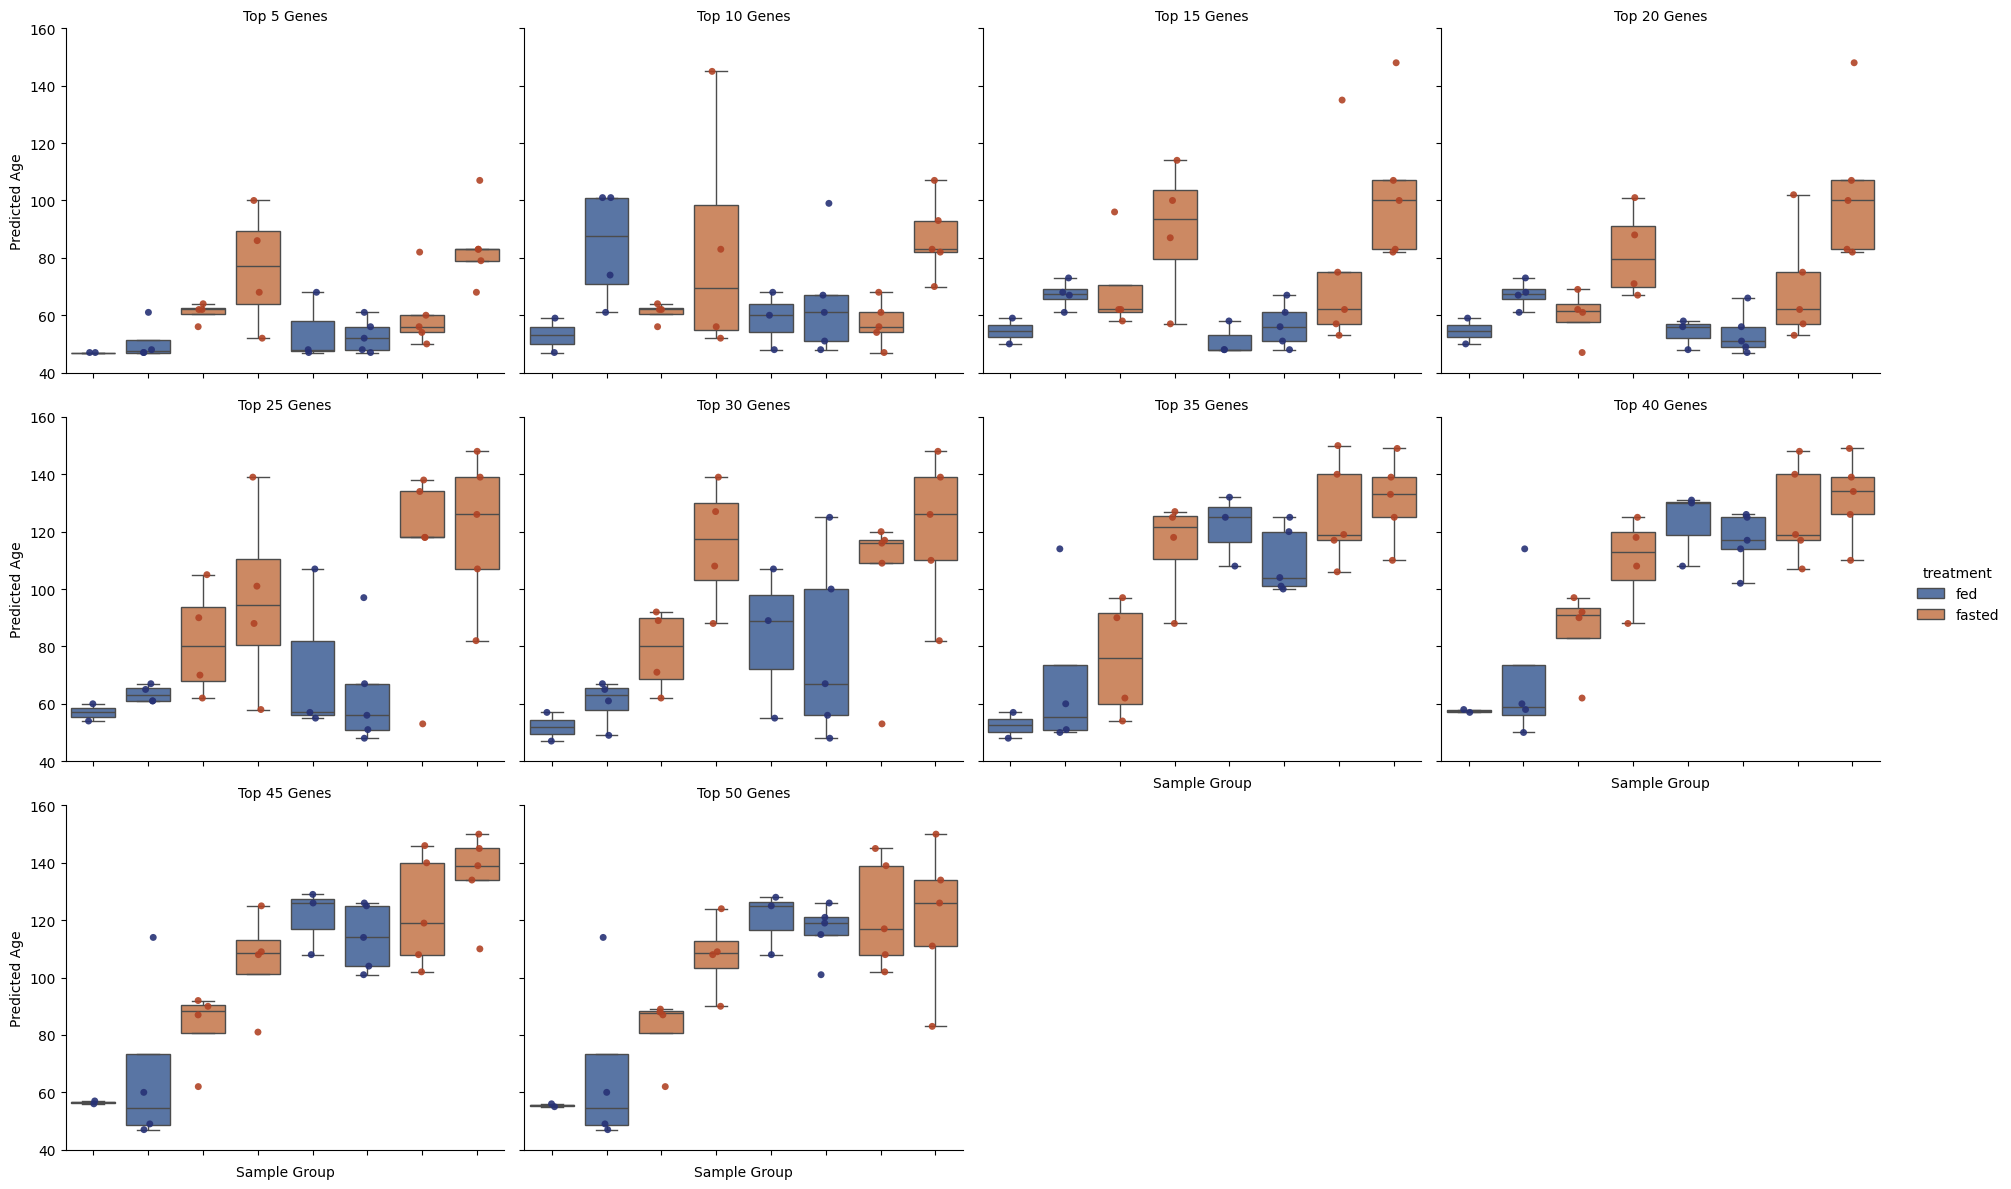

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

# Ordered x-axis
ordered_x = [
    '49_wt_fed', '49_mut_fed',
    '49_wt_fasted', '49_mut_fasted',
    '126_wt_fed', '126_mut_fed',
    '126_wt_fasted', '126_mut_fasted'
]

# Custom palette
custom_palette = ['#273276', '#B14325']

# Load all prediction files
all_predictions_list = []

for gene_number in range(5, 51, 5):
    file_path = f"./predictions/age_preds_top_{gene_number}_genes.tsv"
    if os.path.exists(file_path):
        df = pd.read_csv(file_path, sep="\t", index_col=0)
        df["gene_number"] = str(gene_number)  # for cleaner facet titles
        all_predictions_list.append(df)
    else:
        print(f"Warning: {file_path} not found. Skipping.")

# Concatenate into a single DataFrame
all_predictions_df = pd.concat(all_predictions_list, axis=0)

# Plot with seaborn FacetGrid (catplot)
g = sns.catplot(
    data=all_predictions_df,
    x="age_genotype_treatment",
    y="prediction",
    hue="treatment",
    col="gene_number",
    col_wrap=4,
    kind="box",
    palette='deep',
    order=ordered_x,
    height=4,
    aspect=1.2,
    showfliers=False
)

# Overlay stripplot for better visualization
for ax, gene_number in zip(g.axes.flat, all_predictions_df["gene_number"].unique()):
    subset = all_predictions_df[all_predictions_df["gene_number"] == gene_number]
    sns.stripplot(
        x='age_genotype_treatment',
        y='prediction',
        hue='treatment',
        data=subset,
        palette=custom_palette,
        dodge=False,
        alpha=0.9,
        jitter=True,
        size=5,
        order=ordered_x,
        ax=ax,
        legend=False
    )
    ax.set_title(f"Top {gene_number} Genes")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    ax.set_ylim(40, 160)

g.set_axis_labels("Sample Group", "Predicted Age")
g.set_titles("Top {col_name} Genes")
g.tight_layout()
plt.savefig("./plots/faceted_predictions_by_gene_number.svg", dpi=300, bbox_inches="tight")
plt.show()


# Male - rotate training samples

In [ ]:
#------------------------------------------------------------
# Sample selection setup
#------------------------------------------------------------
#select two AL samples for calibration
all_samples = df_intervention_male.index
WT_samples = df_intervention_male[df_intervention_male['genotype'] == 'wt'].index

#get rid of fed samples, remove the test samples that have "fasted" in the name
WT_samples = [s for s in WT_samples if 'fasted' not in s.lower()]
WT_samples = sorted(WT_samples)

# Separate the samples
young_samples = [s for s in WT_samples if s.startswith("young")]
old_samples = [s for s in WT_samples if s.startswith("old")]

# Create all 2x2 combinations
young_combos = list(itertools.combinations(young_samples, 2))
old_combos = list(itertools.combinations(old_samples, 2))


#------------------------------------------------------------
# Loop through all young-old combinations
#------------------------------------------------------------
for y_combo in young_combos:
    for o_combo in old_combos:

        combo_id = f"{'_'.join(map(str, y_combo))}__{'_'.join(map(str, o_combo))}"
        print(f"\nRunning combo: {combo_id}")

        # Select samples for training
        select_train_samples = list(y_combo) + list(o_combo)
        df_intervention_train = df_intervention_male.loc[select_train_samples]
        df_intervention_train = df_intervention_train[tissue_df_counts.columns]  # match columns

        # Combine with atlas
        atlas_plus_intervention = pd.concat([tissue_df_counts, df_intervention_train], axis=0)
        age_steps = sorted(atlas_plus_intervention["age"].value_counts().index.tolist())

        atlas_plus_intervention = atlas_plus_intervention.drop(atlas_plus_intervention.columns[[-1, -3, -4]], axis=1)

        # Get test set
        test_samples = [s for s in df_intervention_male.index if s not in select_train_samples]
        df_intervention_test = df_intervention_male.loc[test_samples]
        df_intervention_test_counts = df_intervention_test.drop(
            df_intervention_test.columns[[-1, -3, -4, -5,-6]], axis=1
        )

        #check cols ordered the same
        df_intervention_test_counts = df_intervention_test_counts[atlas_plus_intervention.columns]
        df_intervention_test_counts.head(2)

        # Save per-sample reference files
        for sample in atlas_plus_intervention.index:
            atlas_plus_intervention.drop(sample).to_csv(
                f"./reference/fat_sample_{sample}_{combo_id}.csv", sep="\t"
            )

        new_age_steps = np.arange(min(age_steps), max(age_steps) + 1, 1)


        # Run transcriptome_reference (assuming it handles saving internally)
        transcriptome_reference(
            training_matrix=atlas_plus_intervention,
            reference_name=f"killifish_fat_ref_male_{combo_id}",
            output_path="./reference_exhaustive/",
            age_prediction="list",
            age_list=new_age_steps,
            min_age=1,
            max_age=24,
            age_step=1,
            tau=0.7
        )


        # Run predictions for a single gene number or loop over multiple
        for gene_number in range(5, 51, 5):
            df_pred = pd.DataFrame(index=df_intervention_test.index, columns=["prediction"])
            reference_df = pd.read_csv(
                f"./reference_exhaustive/killifish_fat_ref_male_{combo_id}", sep="\t", index_col=0
            )
            top_genes = reference_df["spearman_rank"].abs().nlargest(gene_number).index.tolist()

            for sample in df_intervention_test.index:
                total_reads = df_intervention_test_counts.loc[sample].sum()
                log_sums = []
                for age in new_age_steps:
                    logP = []
                    for gene in top_genes:
                        freq = max(reference_df.loc[gene, str(age)], 1e-10)
                        mu = freq * total_reads
                        obs = df_intervention_test_counts.loc[sample, gene]
                        p = max(poisson.pmf(obs, mu), 0.001)
                        logP.append(np.log(p))
                    log_sums.append(np.sum(logP))

                pred_age = round(float(new_age_steps[np.argmax(log_sums)]), 2)
                df_pred.loc[sample, "prediction"] = pred_age

            # Add metadata and save
            df_pred["treatment"] = df_intervention_test["treatment"]

            # Save prediction results
            df_pred.to_csv(
                f"./predictions_exhaustive/male_pred_top_{gene_number}_{combo_id}.tsv", sep="\t"
            )



Running combo: young_fed_wt_fat_rep_1_young_fed_wt_fat_rep_2__old_fed_wt_fat_rep_1_old_fed_wt_fat_rep_2


/tmp/ipython-input-2002720175.py:41: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p = spearmanr(age_training, gene_frequency)



Reference model dataset written to './reference_exhaustive/killifish_fat_ref_male_young_fed_wt_fat_rep_1_young_fed_wt_fat_rep_2__old_fed_wt_fat_rep_1_old_fed_wt_fat_rep_2'
Report file generated at './reference_exhaustive/killifish_fat_ref_male_young_fed_wt_fat_rep_1_young_fed_wt_fat_rep_2__old_fed_wt_fat_rep_1_old_fed_wt_fat_rep_2.report.txt'
-----------------------------------------------------



Time to run construct reference: 68.367 seconds

The reference is constructed and saved!

Running combo: young_fed_wt_fat_rep_1_young_fed_wt_fat_rep_2__old_fed_wt_fat_rep_1_old_fed_wt_fat_rep_3


/tmp/ipython-input-2002720175.py:41: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p = spearmanr(age_training, gene_frequency)



Reference model dataset written to './reference_exhaustive/killifish_fat_ref_male_young_fed_wt_fat_rep_1_young_fed_wt_fat_rep_2__old_fed_wt_fat_rep_1_old_fed_wt_fat_rep_3'
Report file generated at './reference_exhaustive/killifish_fat_ref_male_young_fed_wt_fat_rep_1_young_fed_wt_fat_rep_2__old_fed_wt_fat_rep_1_old_fed_wt_fat_rep_3.report.txt'
-----------------------------------------------------



Time to run construct reference: 68.189 seconds

The reference is constructed and saved!

Running combo: young_fed_wt_fat_rep_1_young_fed_wt_fat_rep_2__old_fed_wt_fat_rep_1_old_fed_wt_fat_rep_4


...


Reference model dataset written to './reference_exhaustive/killifish_fat_ref_male_young_fed_wt_fat_rep_3_young_fed_wt_fat_rep_4__old_fed_wt_fat_rep_3_old_fed_wt_fat_rep_4'
Report file generated at './reference_exhaustive/killifish_fat_ref_male_young_fed_wt_fat_rep_3_young_fed_wt_fat_rep_4__old_fed_wt_fat_rep_3_old_fed_wt_fat_rep_4.report.txt'
-----------------------------------------------------



Time to run construct reference: 70.766 seconds

The reference is constructed and saved!

Running combo: young_fed_wt_fat_rep_3_young_fed_wt_fat_rep_4__old_fed_wt_fat_rep_3_old_fed_wt_fat_rep_5


/tmp/ipython-input-2002720175.py:41: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p = spearmanr(age_training, gene_frequency)



Reference model dataset written to './reference_exhaustive/killifish_fat_ref_male_young_fed_wt_fat_rep_3_young_fed_wt_fat_rep_4__old_fed_wt_fat_rep_3_old_fed_wt_fat_rep_5'
Report file generated at './reference_exhaustive/killifish_fat_ref_male_young_fed_wt_fat_rep_3_young_fed_wt_fat_rep_4__old_fed_wt_fat_rep_3_old_fed_wt_fat_rep_5.report.txt'
-----------------------------------------------------



Time to run construct reference: 71.786 seconds

The reference is constructed and saved!

Running combo: young_fed_wt_fat_rep_3_young_fed_wt_fat_rep_4__old_fed_wt_fat_rep_4_old_fed_wt_fat_rep_5


/tmp/ipython-input-2002720175.py:41: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p = spearmanr(age_training, gene_frequency)



Reference model dataset written to './reference_exhaustive/killifish_fat_ref_male_young_fed_wt_fat_rep_3_young_fed_wt_fat_rep_4__old_fed_wt_fat_rep_4_old_fed_wt_fat_rep_5'
Report file generated at './reference_exhaustive/killifish_fat_ref_male_young_fed_wt_fat_rep_3_young_fed_wt_fat_rep_4__old_fed_wt_fat_rep_4_old_fed_wt_fat_rep_5.report.txt'
-----------------------------------------------------



Time to run construct reference: 76.228 seconds

The reference is constructed and saved!
